## RQ2 - F4 Boxplots


Reading: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\3.2_Total_Repo.csv


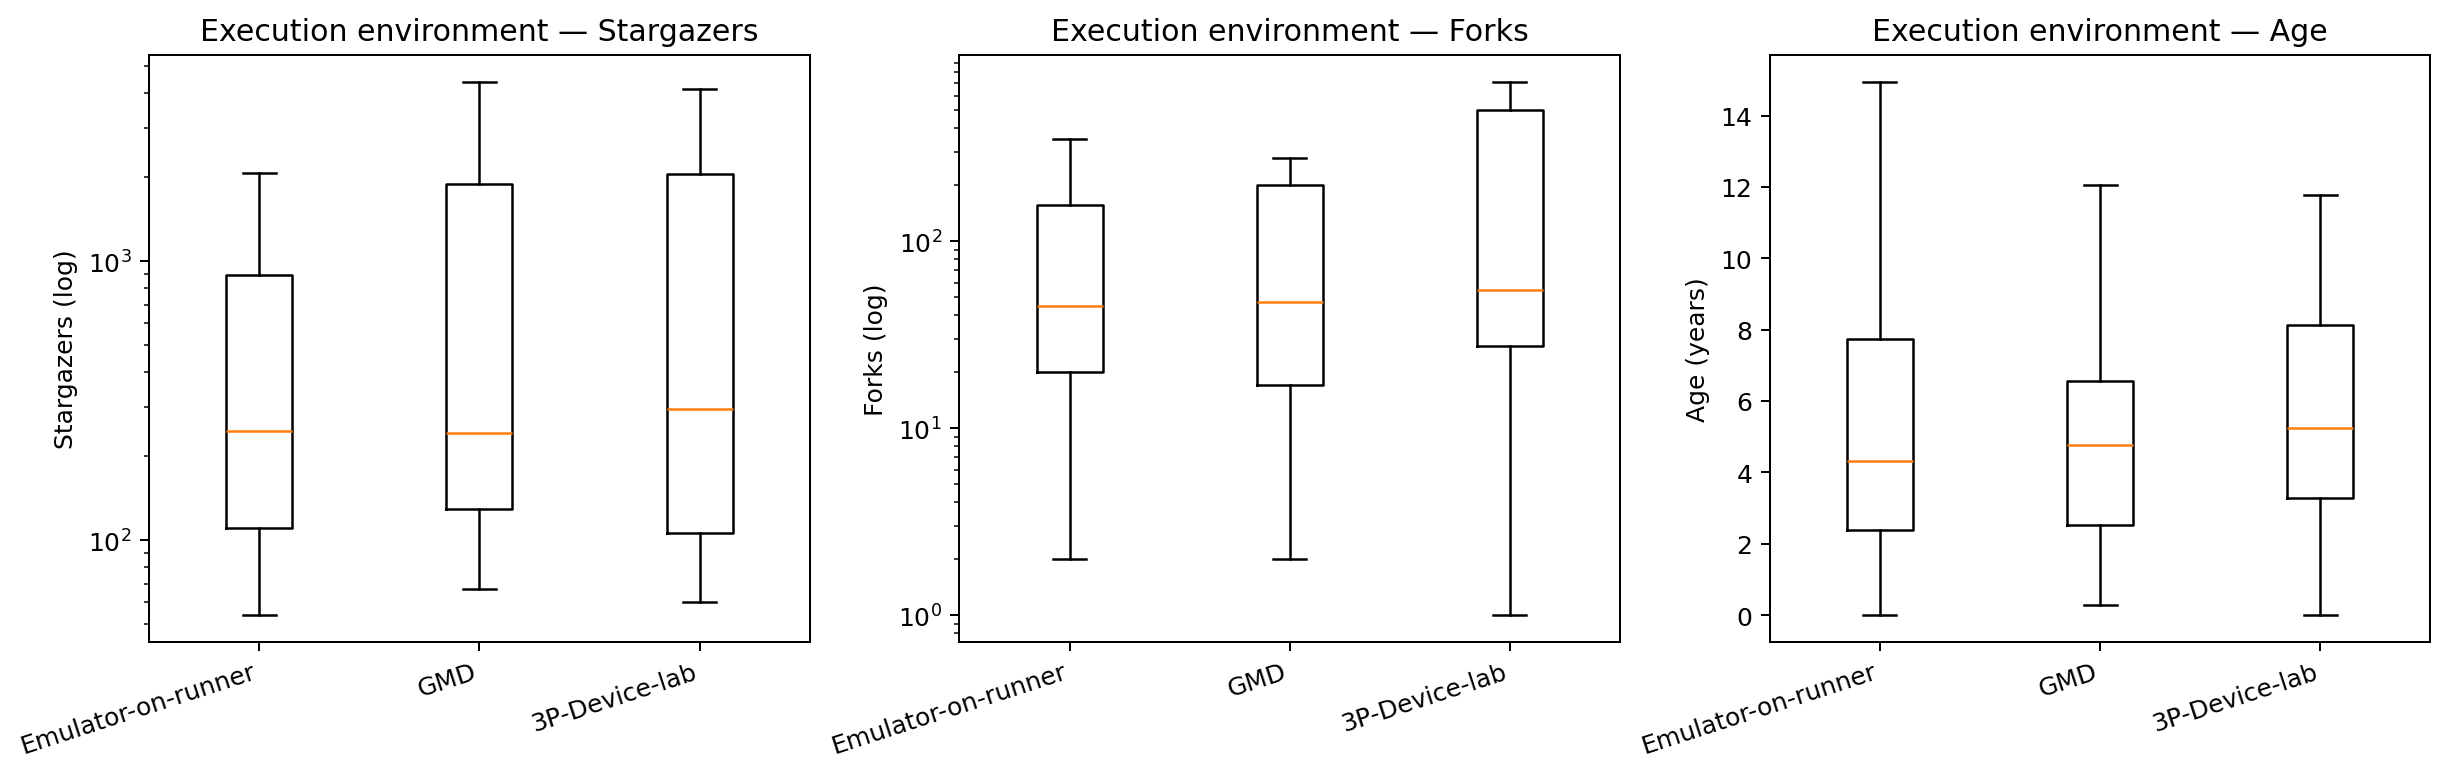

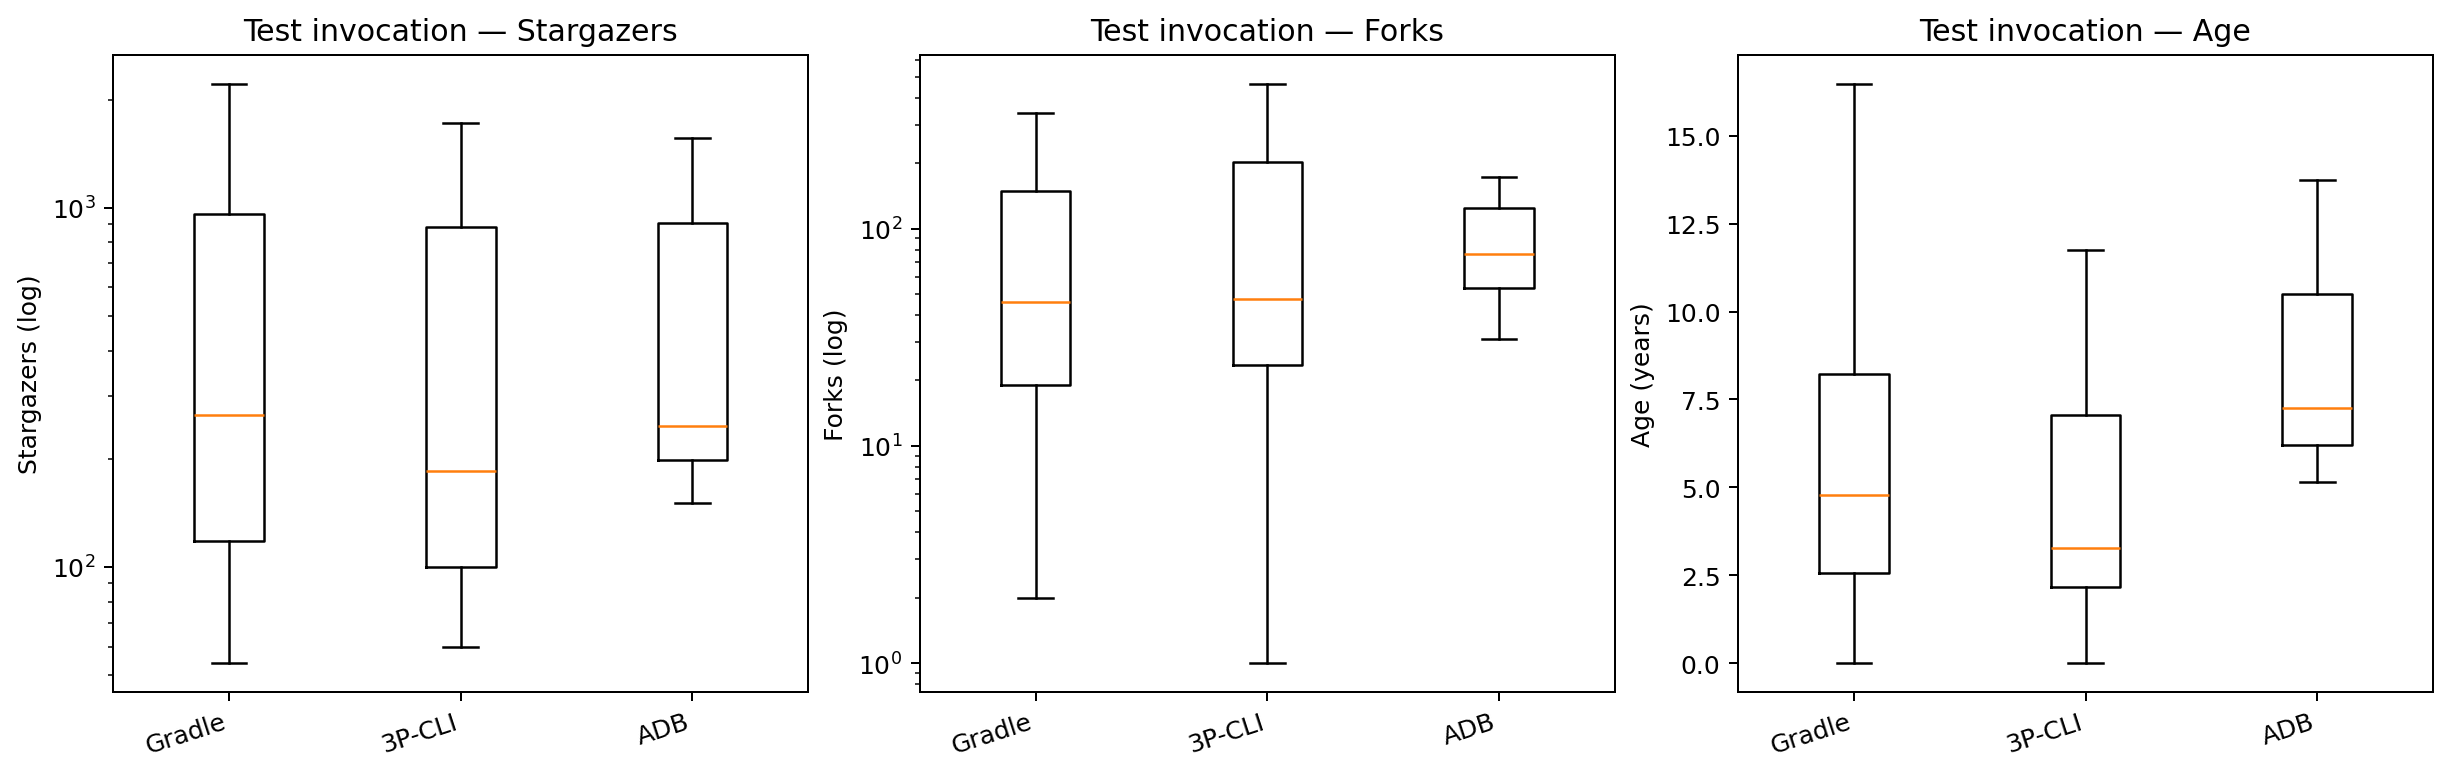

In [1]:
# -*- coding: utf-8 -*-
"""
Box plots for RQ2.4 — execution environments and test invocations (Adopters subset)
- Short labels
- Excludes "Physical device" from execution-environment plots
- Shows figures (does not save)
- NO cohort sizes in x-axis labels
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG — update if needed
# -----------------------------
DATA_DIR = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet"
FILE_NAME = None  # e.g., "5.0_Total_Repo.csv"; keep None to auto-pick the first CSV in the folder
USE_ADOPTERS_ONLY = True
USE_INSTRUMENTATION_ONLY = True
LOG_METRICS_ADD_ONE = True  # add +1 before log scale so zeros are allowed

# Canonical long labels -> short labels
ENV_SHORT = {
    "Emulator on the CI runner": "Emulator-on-runner",
    "Gradle Managed Devices (GMD)": "GMD",
    "Third-party device lab": "3P-Device-lab",
    "Physical device": "Real-device",  # will be excluded from plots
}
INV_SHORT = {
    "Gradle-based": "Gradle",
    "Third-party CLI": "3P-CLI",
    "ADB": "ADB",
}

# Order of styles to display (short labels)
ENV_ORDER_SHORT = ["Emulator-on-runner", "GMD", "3P-Device-lab"]  # excludes "Real-device"
INV_ORDER_SHORT = ["Gradle", "3P-CLI", "ADB"]

# -----------------------------
# Helpers
# -----------------------------
def find_csv(path_dir: str, file_name: str | None) -> Path:
    p = Path(path_dir)
    if file_name:
        fp = p / file_name
        if not fp.exists():
            raise FileNotFoundError(f"CSV not found: {fp}")
        return fp
    candidates = sorted(p.glob("*Total*Repo*.csv")) or sorted(p.glob("*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No CSV found under: {p}")
    return candidates[0]

def parse_dates_and_age(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ["created_at", "updated_at", "pushed_at"]:
        df[col + "_dt"] = pd.to_datetime(df.get(col), utc=True, errors="coerce")
    ref_dt = df["pushed_at_dt"].fillna(df["updated_at_dt"]).fillna(df["created_at_dt"])
    age_days = (ref_dt - df["created_at_dt"]).dt.total_seconds() / (60 * 60 * 24)
    df["age_years"] = age_days / 365.25
    return df

def split_labels(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(",") if x and str(x).strip().lower() != "nan"]

def map_env_labels_raw_to_long(labels):
    """
    Raw examples: Emulator_Generic, Emulator_ReactiveCircus, Emulator_Malinskiy, Emulator_GMD,
                  Third Party, Real Device, Emulator_DIY, Emulator_Other
    """
    mapped = set()
    for lab in labels:
        low = lab.strip().lower()
        if low == "emulator_gmd":
            mapped.add("Gradle Managed Devices (GMD)")
        elif low.startswith("emulator_"):
            mapped.add("Emulator on the CI runner")
        elif low == "third party":
            mapped.add("Third-party device lab")
        elif low == "real device":
            mapped.add("Physical device")
    return mapped

def map_inv_labels_raw_to_long(labels):
    """
    Raw examples: Gradle, Gradle_Connected, Gradle_GMD, 3P CLIs, ADB
    """
    mapped = set()
    for lab in labels:
        low = lab.strip().lower()
        if low.startswith("gradle"):
            mapped.add("Gradle-based")
        elif low == "3p clis":
            mapped.add("Third-party CLI")
        elif low == "adb":
            mapped.add("ADB")
    return mapped

def explode_multi_short(df_base: pd.DataFrame, label_col: str, raw_mapper, short_map: dict, exclude_shorts: set[str] = None) -> pd.DataFrame:
    """
    Returns long-form rows with short labels:
    - raw labels -> canonical long labels -> short labels
    - optionally excludes styles with short labels in exclude_shorts
    """
    exclude_shorts = exclude_shorts or set()
    rows = []
    for _, row in df_base.iterrows():
        long_labels = raw_mapper(split_labels(row.get(label_col)))
        if not long_labels:
            continue
        base = {
            "stargazers_count": row.get("stargazers_count"),
            "forks_count": row.get("forks_count"),
            "age_years": row.get("age_years"),
        }
        for long_lab in long_labels:
            short_lab = short_map.get(long_lab)
            if short_lab is None or short_lab in exclude_shorts:
                continue
            r = dict(base)
            r["style"] = short_lab
            rows.append(r)
    return pd.DataFrame(rows)

def make_group_boxplots(df_long: pd.DataFrame, style_order_short: list[str], title_prefix: str):
    """Show one figure with three subplots (stars, forks, age) for the provided cohort. No cohort sizes in labels."""
    metrics = [
        ("stargazers_count", "Stargazers (log)"),
        ("forks_count", "Forks (log)"),
        ("age_years", "Age (years)"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), dpi=180, constrained_layout=True)

    for ax, (metric, ylabel) in zip(axes, metrics):
        data = []
        labels = []
        for style in style_order_short:
            vals = pd.to_numeric(df_long.loc[df_long["style"] == style, metric], errors="coerce").dropna().astype(float)
            if metric != "age_years" and LOG_METRICS_ADD_ONE:
                vals = vals + 1.0  # allow zeros on log scale
            data.append(vals.values)
            labels.append(style)  # NO cohort sizes in labels

        # Skip entirely empty cohorts (just in case)
        nonempty = [(d, l) for d, l in zip(data, labels) if len(d) > 0]
        if not nonempty:
            ax.set_visible(False)
            continue
        data, labels = zip(*nonempty)

        ax.boxplot(data, showfliers=False)
        ax.set_xticklabels(labels, rotation=18, ha="right")
        ax.set_ylabel(ylabel)
        if metric != "age_years":
            ax.set_yscale("log")
        ax.set_title(f"{title_prefix} — {ylabel.split('(')[0].strip()}")

    return fig, axes

# -----------------------------
# Main
# -----------------------------
def main():
    csv_path = find_csv(DATA_DIR, FILE_NAME)
    print(f"Reading: {csv_path}")
    df = pd.read_csv(csv_path)

    if USE_ADOPTERS_ONLY and "Adopters" in df.columns:
        df = df[df["Adopters"] == True].copy()
    if USE_INSTRUMENTATION_ONLY and "Instru_test" in df.columns:
        df = df[df["Instru_test"] == True].copy()

    df = parse_dates_and_age(df)

    # Sanity check
    for required in ["execution_environment", "test_invocation", "stargazers_count", "forks_count"]:
        if required not in df.columns:
            raise KeyError(f"Missing column: {required}")

    # Build long-form data with short labels
    env_long_short = explode_multi_short(
        df, "execution_environment", map_env_labels_raw_to_long, ENV_SHORT,
        exclude_shorts={"Real device"}  # exclude physical/real device from plotting
    )
    inv_long_short = explode_multi_short(
        df, "test_invocation", map_inv_labels_raw_to_long, INV_SHORT
    )

    # Show grouped box plots (no saving)
    make_group_boxplots(env_long_short, ENV_ORDER_SHORT, "Execution environment")
    make_group_boxplots(inv_long_short, INV_ORDER_SHORT, "Test invocation")

    plt.show()

if __name__ == "__main__":
    main()


Observation 2.4

In [3]:
import os
import re
import math
import pandas as pd

# ---- CONFIG ----
DATA_DIR = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet"
CSV_NAME = "5.0_Total_Repo.csv"
PATH = os.path.join(DATA_DIR, CSV_NAME)

# ---- LOAD ----
df = pd.read_csv(PATH)
# normalize column names a bit
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# ---- HELPERS ----
def pick(colnames):
    """Return the first column from 'colnames' that exists in df, else None."""
    for c in colnames:
        if c in df.columns:
            return c
    return None

def parse_multi(s):
    """Split a multi-label string on comma/pipe/semicolon into a list of tokens."""
    if pd.isna(s):
        return []
    return [p.strip() for p in re.split(r"[|,;]", str(s)) if p.strip()]

def med_iqr(series):
    """Return median, Q1, Q3 of a numeric series (floats), or (None, None, None) if empty."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return None, None, None
    q1, med, q3 = s.quantile([0.25, 0.5, 0.75])
    return float(med), float(q1), float(q3)

def fmt_triplet(med, q1, q3, decimals=0):
    """
    Format as 'median [Q1--Q3]'; avoid stripping zeros for integer outputs.
    This prevents 150 -> '15' or 30 -> '3'.
    """
    def fmt(x):
        if x is None or (isinstance(x, float) and (math.isnan(x) or math.isinf(x))):
            return "NA"
        if decimals == 0:
            # Keep integer formatting exactly (150 stays 150)
            return str(int(round(x)))
        s = f"{x:.{decimals}f}"
        # strip trailing zeros only after the decimal point
        if "." in s:
            s = s.rstrip("0").rstrip(".")
        return s
    return f"{fmt(med)} [{fmt(q1)}--{fmt(q3)}]"

# ---- REQUIRED COLUMNS ----
col_adopt = pick(["RQ1_F1", "rq1_f1"])
col_env   = pick(["execution_environment", "Execution_environment"])
col_inv   = pick(["test_invocation", "Test_invocation"])
col_star  = pick(["stargazers_count", "stars", "Stars"])
col_fork  = pick(["forks_count", "fork", "Forks"])
col_age   = pick(["repo_age", "age_years", "Repository_age_in_years", "repository_age_years"])

missing = [("RQ1_F1", col_adopt), ("execution_environment", col_env), ("test_invocation", col_inv),
           ("stargazers_count", col_star), ("forks_count/fork", col_fork), ("repo_age", col_age)]
missing = [name for name, found in missing if found is None]
if missing:
    raise ValueError(f"Missing expected column(s): {', '.join(missing)}")

# ---- ADOPTERS SUBSET ----
adopter_values = {"Gradle_Only_Configured", "Partially_CI_Configured", "Fully_CI_Automated"}
df["is_adopter"] = df[col_adopt].isin(adopter_values)
ad = df[df["is_adopter"]].copy()

# ---- MAP EXECUTION ENVIRONMENT TOKENS TO TAXONOMY ----
def map_env_label(raw):
    r = raw.strip().lower()
    # Emulator on CI runner: community vs custom
    if r in {"emulator_reactivecircus", "emulator_malinskiy", "emulator_other"}:
        return "Emulator on the CI runner"
    if r in {"emulator_diy"}:
        return "Emulator on the CI runner"
    # GMD
    if r in {"emulator_gmd", "gmd", "gradle_managed_devices"}:
        return "Gradle Managed Devices (GMD)"
    # Third-party device lab
    if r in {"third party", "third_party", "third-party"}:
        return "Third-party device lab"
    # Physical device
    if r in {"real device", "physical_device", "physical device"}:
        return "Physical device"
    return None

# ---- MAP TEST INVOCATION TOKENS TO TAXONOMY ----
def map_inv_label(raw):
    r = raw.strip().lower()
    if r in {"gradle_connected", "gradle_gmd", "gradle"}:
        return "Gradle-based"
    if r in {"3p clis", "3p_cli", "third_party_cli", "third party cli"}:
        return "Third-party CLI"
    if r == "adb":
        return "ADB"
    return None

# Build canonical multi-label columns (dedup within a row after mapping)
ad["env_labels"] = ad[col_env].apply(parse_multi).apply(
    lambda toks: sorted({m for t in toks if (m := map_env_label(t))})
)
ad["inv_labels"] = ad[col_inv].apply(parse_multi).apply(
    lambda toks: sorted({m for t in toks if (m := map_inv_label(t))})
)

# ---- BUILD TABLE A: EXECUTION ENVIRONMENT (N + medians/IQRs) ----
env_styles = ["Emulator on the CI runner", "Gradle Managed Devices (GMD)",
              "Third-party device lab", "Physical device"]

rows_env = []
for env_name in env_styles:
    mask = ad["env_labels"].apply(lambda lst: env_name in lst)
    idx = ad.index[mask]
    N = len(idx)
    stars_med, stars_q1, stars_q3 = med_iqr(ad.loc[idx, col_star])
    forks_med, forks_q1, forks_q3 = med_iqr(ad.loc[idx, col_fork])
    age_med,   age_q1,   age_q3   = med_iqr(ad.loc[idx, col_age])
    rows_env.append({
        "Style": env_name,
        "N": N,
        "Stars median [Q1--Q3]": fmt_triplet(stars_med, stars_q1, stars_q3, decimals=0),
        "Forks median [Q1--Q3]": fmt_triplet(forks_med, forks_q1, forks_q3, decimals=0),
        "Age (years) median [Q1--Q3]": fmt_triplet(age_med, age_q1, age_q3, decimals=1),
    })

table_env = pd.DataFrame(rows_env, columns=[
    "Style", "N", "Stars median [Q1--Q3]", "Forks median [Q1--Q3]", "Age (years) median [Q1--Q3]"
])

# ---- BUILD TABLE B: TEST INVOCATION (N + medians/IQRs) ----
inv_styles = ["Gradle-based", "Third-party CLI", "ADB"]

rows_inv = []
for inv_name in inv_styles:
    mask = ad["inv_labels"].apply(lambda lst: inv_name in lst)
    idx = ad.index[mask]
    N = len(idx)
    stars_med, stars_q1, stars_q3 = med_iqr(ad.loc[idx, col_star])
    forks_med, forks_q1, forks_q3 = med_iqr(ad.loc[idx, col_fork])
    age_med,   age_q1,   age_q3   = med_iqr(ad.loc[idx, col_age])
    rows_inv.append({
        "Style": inv_name,
        "N": N,
        "Stars median [Q1--Q3]": fmt_triplet(stars_med, stars_q1, stars_q3, decimals=0),
        "Forks median [Q1--Q3]": fmt_triplet(forks_med, forks_q1, forks_q3, decimals=0),
        "Age (years) median [Q1--Q3]": fmt_triplet(age_med, age_q1, age_q3, decimals=1),
    })

table_inv = pd.DataFrame(rows_inv, columns=[
    "Style", "N", "Stars median [Q1--Q3]", "Forks median [Q1--Q3]", "Age (years) median [Q1--Q3]"
])

# ---- DISPLAY ----
print("\n=== RQ2 · Execution Environment (Adopters) ===")
print(table_env.to_string(index=False))

print("\n=== RQ2 · Test Invocation (Adopters) ===")
print(table_inv.to_string(index=False))

# ---- OPTIONAL: quick sanity prints you can comment out ----
# Count how many adopters have ≥1 env/≥1 inv (multi-label presence)
env_any = int((ad["env_labels"].apply(len) >= 1).sum())
inv_any = int((ad["inv_labels"].apply(len) >= 1).sum())
print(f"\n[Sanity] Repos with ≥1 execution environment: {env_any}")
print(f"[Sanity] Repos with ≥1 invocation: {inv_any}")



=== RQ2 · Execution Environment (Adopters) ===
                       Style   N Stars median [Q1--Q3] Forks median [Q1--Q3] Age (years) median [Q1--Q3]
   Emulator on the CI runner 327        245 [110--893]          44 [19--156]              7.6 [4.5--9.9]
Gradle Managed Devices (GMD)  19       241 [129--1890]          46 [16--198]              5.3 [2.9--6.6]
      Third-party device lab  19       294 [106--2062]          54 [26--499]              7.1 [5.2--8.7]
             Physical device   1        150 [150--150]           30 [30--30]           13.8 [13.8--13.8]

=== RQ2 · Test Invocation (Adopters) ===
          Style   N Stars median [Q1--Q3] Forks median [Q1--Q3] Age (years) median [Q1--Q3]
   Gradle-based 251        263 [117--957]          45 [18--148]               7.7 [4.6--10]
Third-party CLI  28         184 [99--882]          46 [22--201]              5.2 [2.4--7.6]
            ADB   3        245 [198--905]          75 [52--123]             9.2 [8.2--11.5]

[Sanity] Repos w